# Autoencoders

### 1. ORIGINAL (propuesto por Vanessa)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt


# Cargar MNIST
(X_train, _), (X_test, _) = tf.keras.datasets.mnist.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Aplanar (784)
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)


# Definir Autoencoder

encoding_dim = 32  # compresión fuerte

input_img = tf.keras.Input(shape=(784,))

# Encoder
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = layers.Dense(128, activation='relu')(encoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

autoencoder = models.Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Entrenamiento

autoencoder.fit(
    X_train,
    X_train,   # <- importante: entrada = salida
    epochs=15,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test)
)

# Reconstrucción

decoded_imgs = autoencoder.predict(X_test[:10])

# Visualización

n = 10
plt.figure(figsize=(20, 4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstruida
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstruida")
    plt.axis('off')

plt.show()

### 2. Dataset = CIFAR-10

#### 2.1. 2 layers

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Cargar CIFAR-10
(X_train, _), (X_test, _) = tf.keras.datasets.cifar100.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Input correcto
input_img = tf.keras.Input(shape=(32,32,3))

# Encoder
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2), padding='same')(x)

encoded = layers.Conv2D(128,(3,3), activation='relu', padding='same')(x)

# Decoder
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2,2))(x)

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)

decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

# Modelo
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mae')

# Entrenamiento
autoencoder.fit(
    X_train, X_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test)
)

# Predicción
decoded_imgs = autoencoder.predict(X_test[:5])

#### 1.2.2. 3 layers

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Cargar CIFAR-10
(X_train, _), (X_test, _) = tf.keras.datasets.cifar10.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Input correcto
input_img = tf.keras.Input(shape=(32,32,3))

# Encoder
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(e1)
ep1 = layers.MaxPooling2D((2,2), padding='same')(e1)

e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(ep1)
e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(e2)
ep2 = layers.MaxPooling2D((2,2), padding='same')(e2)

e3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(ep2)
e3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(e3)
ep3 = layers.MaxPooling2D((2,2), padding='same')(e3)

# Bottleneck
bn = layers.Conv2D(256,(3,3), activation='relu', padding='same')(ep3)
bn = layers.Conv2D(256,(3,3), activation='relu', padding='same')(bn)

# Decoder
d1 = layers.UpSampling2D((2,2))(bn)
d1 = layers.Concatenate()([d1, e3])
d1 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(d1)
d1 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(d1)

d2 = layers.UpSampling2D((2,2))(d1)
d2 = layers.Concatenate()([d2, e2])
d2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d2)
d2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d2)

d3 = layers.UpSampling2D((2,2))(d2)
d3 = layers.Concatenate()([d3, e1])
d3 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d3)
d3 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d3)

decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(d3)

# Modelo
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mae')

# Entrenamiento
autoencoder.fit(
    X_train, X_train,
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test, X_test)
)

# Predicción
decoded_imgs = autoencoder.predict(X_test[:5])

##### 1.2.3: 2 layers, menos kernels

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Cargar CIFAR-10
(X_train, _), (X_test, _) = tf.keras.datasets.cifar10.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Input correcto
input_img = tf.keras.Input(shape=(32,32,3))

# Encoder
e1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(input_img)
e1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(e1)
ep1 = layers.MaxPooling2D((2,2), padding='same')(e1)

e2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(ep1)
e2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(e2)
ep2 = layers.MaxPooling2D((2,2), padding='same')(e2)

# Bottleneck
bn = layers.Conv2D(64,(3,3), activation='relu', padding='same')(ep2)
bn = layers.Conv2D(64,(3,3), activation='relu', padding='same')(bn)

# Decoder

d1 = layers.UpSampling2D((2,2))(bn)
d1 = layers.Concatenate()([d1, e2])
d1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d1)
d1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d1)

d2 = layers.UpSampling2D((2,2))(d1)
d2 = layers.Concatenate()([d2, e1])
d2 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(d2)
d2 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(d2)

decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(d2)

# Modelo
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mae')

# Entrenamiento
autoencoder.fit(
    X_train, X_train,
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test, X_test)
)

# Predicción
decoded_imgs = autoencoder.predict(X_test[:5])

#### VISUALIZAR

In [ ]:
# Visualización
n = 5
plt.figure(figsize=(10,4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(X_test[i])
    plt.title("Original")
    plt.axis('off')

    # Reconstruida
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstruida")
    plt.axis('off')

plt.show()

## 3. Pruebas con Dataset RealWaste

#### 3.1. No convolucional

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

layers = tf.keras.layers
models = tf.keras.models
utils = tf.keras.utils

directory = 'datasets/realwaste-main/RealWaste/'

# Dataset
train_dataset = utils.image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="training",
    batch_size=32,
    image_size=(64,64),
    shuffle=True,
    seed=12,
)

val_dataset = utils.image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="validation",
    batch_size=32,
    image_size=(64,64),
    shuffle=True,
    seed=12,
)

encoding_dim = 32

def preprocess(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, x 

train_dataset = train_dataset.map(preprocess)
val_dataset = val_dataset.map(preprocess)


input_img = tf.keras.Input(shape=(64,64,3))

# Encoder
x = layers.Flatten()(input_img)
x = layers.Dense(3072, activation='relu')(x)
x = layers.Dense(768, activation='relu')(x)
encoded = layers.Dense(encoding_dim, activation='relu')(x)

# Decoder
x = layers.Dense(768, activation='relu')(encoded)
x = layers.Dense(3072, activation='relu')(x)
x = layers.Dense(64*64*3, activation='sigmoid')(x)
decoded = layers.Reshape((64,64,3))(x)

autoencoder = models.Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Entrenamiento
autoencoder.fit(
    train_dataset,
    epochs=3,
    validation_data=val_dataset
)

# Reconstrucción
for batch in val_dataset.take(1):
    imgs, _ = batch
    decoded_imgs = autoencoder.predict(imgs[:10])

    n = 10
    plt.figure(figsize=(20, 4))

    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(imgs[i])
        plt.title("Original")
        plt.axis('off')

        # Reconstruida
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i])
        plt.title("Reconstruida")
        plt.axis('off')

    plt.show()

#### 3.2. Convolucional

In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

layers = tf.keras.layers
models = tf.keras.models
utils = tf.keras.utils

directory = 'datasets/realwaste-main/RealWaste/'

# Dataset
train_dataset = utils.image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="training",
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    seed=12,
)

val_dataset = utils.image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="validation",
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    seed=12,
)

def preprocess(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, x 

train_dataset = train_dataset.map(preprocess)
val_dataset = val_dataset.map(preprocess)


input_img = layers.Input(shape=(128,128,3))

# Encoder
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(e1)
ep1 = layers.MaxPooling2D((2,2), padding='same')(e1)

e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(ep1)
e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(e2)
ep2 = layers.MaxPooling2D((2,2), padding='same')(e2)

e3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(ep2)
e3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(e3)
ep3 = layers.MaxPooling2D((2,2), padding='same')(e3)

# Bottleneck
bn = layers.Conv2D(256,(3,3), activation='relu', padding='same')(ep3)
bn = layers.Conv2D(256,(3,3), activation='relu', padding='same')(bn)

# Decoder
d1 = layers.UpSampling2D((2,2))(bn)
d1 = layers.Concatenate()([d1, e3])
d1 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(d1)
d1 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(d1)

d2 = layers.UpSampling2D((2,2))(d1)
d2 = layers.Concatenate()([d2, e2])
d2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d2)
d2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d2)

d3 = layers.UpSampling2D((2,2))(d2)
d3 = layers.Concatenate()([d3, e1])
d3 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d3)
d3 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d3)

decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(d3)

autoencoder = models.Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='mse')

# Entrenamiento
autoencoder.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset
)


Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - loss: 0.0123 - val_loss: 0.0030
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - loss: 0.0019 - val_loss: 7.6396e-04
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - loss: 6.2500e-04 - val_loss: 8.9537e-04
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - loss: 4.2312e-04 - val_loss: 3.1322e-04
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - loss: 3.7945e-04 - val_loss: 2.7552e-04
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 362s 3s/step - loss: 2.8751e-04 - val_loss: 2.3944e-04
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - loss: 2.6002e-04 - val_loss: 1.9565e-04
Epoch 8/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 453s 4s/step - loss: 2.5601e-04 - val_loss: 1.7963e-04
Epoch 9/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 568s 4s/step - loss: 2.6454e-04 - val_loss: 2.5521e-04
Epoch 10/10


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


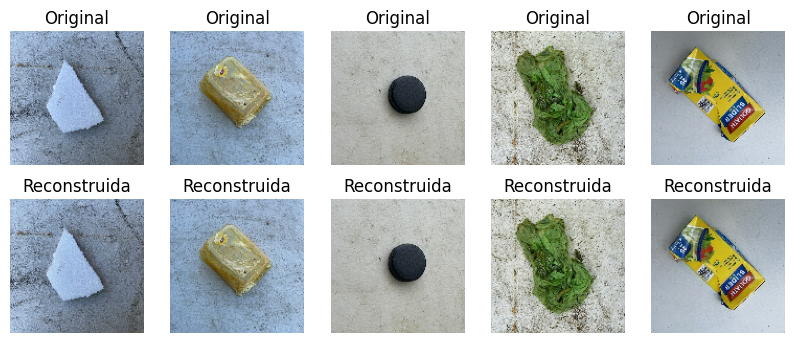

In [8]:
# Reconstrucción
for batch in val_dataset.take(1):
    imgs, _ = batch
    decoded_imgs = autoencoder.predict(imgs[:5])

    n = 5
    plt.figure(figsize=(10, 4))

    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(imgs[i])
        plt.title("Original")
        plt.axis('off')

        # Reconstruida
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i])
        plt.title("Reconstruida")
        plt.axis('off')

    plt.show()